# **Object Detection: YOLOv11 on COCO **

This notebook is a Colab-ready variant that saves checkpoints locally.

Goals:
- Train and compare **YOLO11n** and **YOLO11s**.
- Keep 2 separate training cells (one per model).
- Resume after Colab quota interruption using `last.pt`.


## **1. Chuẩn bị môi trường**
Chạy cell này để cài các thư viện cần thiết.

In [13]:
%pip install -q ultralytics==8.3.0 pycocotools pandas seaborn pyyaml


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
import json
import random
from pathlib import Path
import os

os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"
os.environ["WANDB_SILENT"] = "true"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from IPython.display import display
from ultralytics import YOLO
from ultralytics.data.utils import check_det_dataset

sns.set_theme(style='whitegrid')
random.seed(42)
np.random.seed(42)

## **Local output setup**
- Không dùng Google Drive.
- Toàn bộ kết quả lưu ở `assignment_2/runs`.

In [15]:
def resolve_runs_root():
    cwd = Path.cwd()
    if cwd.name == 'assignment_2':
        return cwd / 'runs'
    if (cwd / 'assignment_2').exists():
        return cwd / 'assignment_2' / 'runs'
    return cwd / 'assignment_2' / 'runs'


RUNS_ROOT = resolve_runs_root()
RUNS_ROOT.mkdir(parents=True, exist_ok=True)

print(f'RUNS_ROOT={RUNS_ROOT.resolve()}')

RUNS_ROOT=/Users/ngonhattoan/IdeaProjects/CO5085_DeepLearning_CV/assignment_2/runs


## **2. Thiết lập bài toán và dữ liệu**
- Mặc định notebook train **full COCO** để làm báo cáo.
- Dùng flag `USE_COCO128_DEBUG` để đổi sang `coco128.yaml` khi cần chạy nhanh để debug.

In [16]:
USE_COCO128_DEBUG = False  # False: full COCO, True: quick debug with coco128
DATA_YAML = 'coco128.yaml' if USE_COCO128_DEBUG else 'coco.yaml'

# Persist all runs under assignment_2/runs.
PROJECT_DIR = RUNS_ROOT / 'assignment2_yolov11_coco'
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

data_info = check_det_dataset(DATA_YAML)
print(f'Using dataset config: {DATA_YAML}')
print(f'Project dir: {PROJECT_DIR}')
data_info

Using dataset config: coco.yaml
Project dir: /Users/ngonhattoan/IdeaProjects/CO5085_DeepLearning_CV/assignment_2/runs/assignment2_yolov11_coco


{'path': PosixPath('/Users/ngonhattoan/IdeaProjects/datasets/coco'),
 'train': '/Users/ngonhattoan/IdeaProjects/datasets/coco/train2017.txt',
 'val': '/Users/ngonhattoan/IdeaProjects/datasets/coco/val2017.txt',
 'test': '/Users/ngonhattoan/IdeaProjects/datasets/coco/test-dev2017.txt',
 'names': {0: 'person',
  1: 'bicycle',
  2: 'car',
  3: 'motorcycle',
  4: 'airplane',
  5: 'bus',
  6: 'train',
  7: 'truck',
  8: 'boat',
  9: 'traffic light',
  10: 'fire hydrant',
  11: 'stop sign',
  12: 'parking meter',
  13: 'bench',
  14: 'bird',
  15: 'cat',
  16: 'dog',
  17: 'horse',
  18: 'sheep',
  19: 'cow',
  20: 'elephant',
  21: 'bear',
  22: 'zebra',
  23: 'giraffe',
  24: 'backpack',
  25: 'umbrella',
  26: 'handbag',
  27: 'tie',
  28: 'suitcase',
  29: 'frisbee',
  30: 'skis',
  31: 'snowboard',
  32: 'sports ball',
  33: 'kite',
  34: 'baseball bat',
  35: 'baseball glove',
  36: 'skateboard',
  37: 'surfboard',
  38: 'tennis racket',
  39: 'bottle',
  40: 'wine glass',
  41: 'cup',

In [17]:
import zipfile

# The labels zip file is usually downloaded to the parent directory of data_info['path']
labels_zip_path = Path(data_info['path']).parent / 'coco2017labels-segments.zip'
labels_extract_dir = Path(data_info['path'])

if labels_zip_path.exists():
    print(f'Extracting labels from {labels_zip_path} to {labels_extract_dir}...')
    with zipfile.ZipFile(labels_zip_path, 'r') as zip_ref:
        zip_ref.extractall(labels_extract_dir)
    print('Labels extracted successfully.')
else:
    print(f'Labels zip file not found at {labels_zip_path}. Please ensure it was downloaded.')

Extracting labels from /Users/ngonhattoan/IdeaProjects/datasets/coco2017labels-segments.zip to /Users/ngonhattoan/IdeaProjects/datasets/coco...
Labels extracted successfully.


## **3. Phân tích tập dữ liệu (EDA)**
Phần này thống kê quy mô dữ liệu và phân bố lớp để kiểm tra mức độ đa dạng cũng như tính mất cân bằng trong tập train.

In [18]:
def resolve_path(base_path, value):
    p = Path(value)
    return p if p.is_absolute() else (Path(base_path) / p)


train_list_file = resolve_path(data_info.get('path', '.'), data_info['train'])
val_list_file = resolve_path(data_info.get('path', '.'), data_info['val'])


def get_images_from_list_file(list_file_path, base_data_path):
    images = []
    if list_file_path.is_file() and list_file_path.suffix.lower() == '.txt':
        with open(list_file_path, 'r', encoding='utf-8') as f:
            for line in f:
                s = line.strip()
                if not s:
                    continue
                p = Path(s)
                if not p.is_absolute():
                    p = Path(base_data_path) / p
                if p.exists() and p.is_file():
                    images.append(p)
    elif list_file_path.is_dir():
        images = sorted(
            list(list_file_path.glob('*.jpg')) +
            list(list_file_path.glob('*.jpeg')) +
            list(list_file_path.glob('*.png'))
        )
    return sorted(images)


train_images = get_images_from_list_file(train_list_file, data_info.get('path', '.'))
val_images = get_images_from_list_file(val_list_file, data_info.get('path', '.'))

base_data_path = Path(data_info.get('path', '.'))

if train_images:
    train_split_dir_name = train_images[0].parent.name
    label_train_path = base_data_path / 'labels' / train_split_dir_name
else:
    label_train_path = base_data_path / 'labels' / 'train2017'

if val_images:
    val_split_dir_name = val_images[0].parent.name
    label_val_path = base_data_path / 'labels' / val_split_dir_name
else:
    label_val_path = base_data_path / 'labels' / 'val2017'

print(f'Train images list file: {train_list_file}')
print(f'Train images: {len(train_images)}')
print(f'Val images list file:   {val_list_file}')
print(f'Val images:   {len(val_images)}')
print(f'Classes:      {len(data_info["names"])}')
print(f'Label train path: {label_train_path}')
print(f'Label val path: {label_val_path}')


Train images list file: /Users/ngonhattoan/IdeaProjects/datasets/coco/train2017.txt
Train images: 118287
Val images list file:   /Users/ngonhattoan/IdeaProjects/datasets/coco/val2017.txt
Val images:   5000
Classes:      80
Label train path: /Users/ngonhattoan/IdeaProjects/datasets/coco/labels/train2017
Label val path: /Users/ngonhattoan/IdeaProjects/datasets/coco/labels/val2017


,class_id,class_name,instances
0,0,person,257252
2,2,car,43531
56,56,chair,38073
73,73,book,24077
39,39,bottle,24070
41,41,cup,20574
60,60,dining table,15694
45,45,bowl,14323
9,9,traffic light,12842
26,26,handbag,12342


/var/folders/1q/14n6gkv50_g3hq9v3dc67t6h0000gn/T/ipykernel_6121/2642564043.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dist_df.head(15), x='instances', y='class_name', palette='viridis')


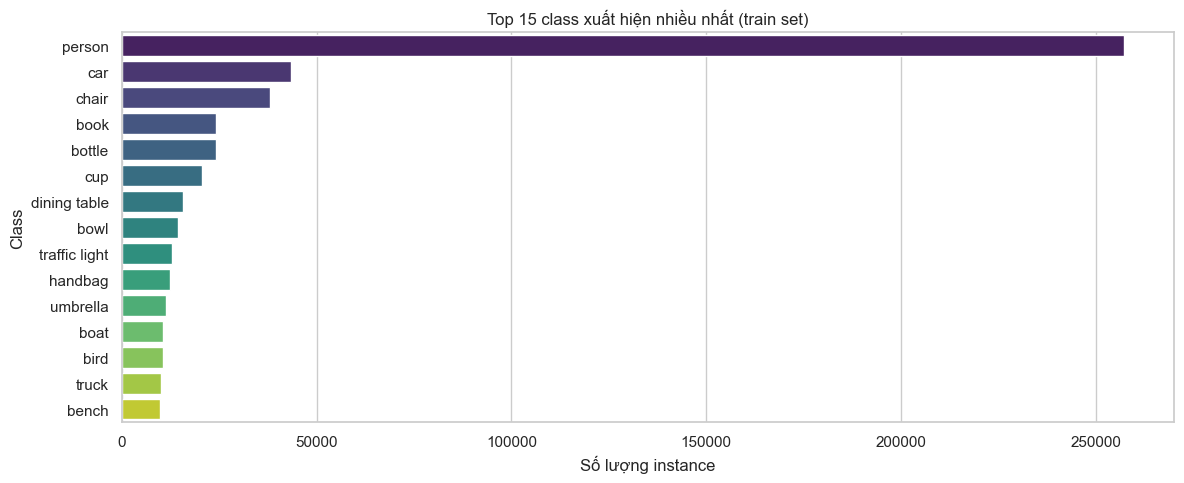

In [19]:
def count_class_distribution(label_dir, class_names):
    counts = {i: 0 for i in range(len(class_names))}
    for lb in sorted(label_dir.glob('*.txt')):
        with open(lb, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cls_idx = int(float(parts[0]))
                if cls_idx in counts:
                    counts[cls_idx] += 1

    df = pd.DataFrame({
        'class_id': list(counts.keys()),
        'class_name': [class_names[i] for i in counts.keys()],
        'instances': list(counts.values())
    }).sort_values('instances', ascending=False)
    return df


class_names = data_info['names']
dist_df = count_class_distribution(label_train_path, class_names)
display(dist_df.head(15))

plt.figure(figsize=(12, 5))
sns.barplot(data=dist_df.head(15), x='instances', y='class_name', palette='viridis')
plt.title('Top 15 class xuất hiện nhiều nhất (train set)')
plt.xlabel('Số lượng instance')
plt.ylabel('Class')
plt.tight_layout()
plt.show()

Từ biểu đồ phân bố lớp, có thể nhận thấy tần suất xuất hiện giữa các lớp không đồng đều. Đây là đặc điểm phổ biến của COCO và có thể ảnh hưởng trực tiếp đến chất lượng phát hiện ở các lớp hiếm.

Trong quá trình phân tích kết quả, cần theo dõi thêm lỗi false negative/false positive theo từng nhóm lớp để có đánh giá đầy đủ hơn.

## **4. Cấu hình huấn luyện mô hình**
Thiết lập cấu hình chung cho các thí nghiệm nhằm đảm bảo tính công bằng khi so sánh YOLO11n và YOLO11s.

In [20]:
TRAIN_ARGS = {
    'data': DATA_YAML,
    'imgsz': 640,
    'epochs': 5,
    'batch': 16,
    'workers': 4,
    'project': str(PROJECT_DIR),
    'pretrained': True,
    'optimizer': 'auto',
    'seed': 42,
    'patience': 20,
    'cos_lr': True,
    'close_mosaic': 10,
    'save_period': 1,
    'exist_ok': True
}
TRAIN_ARGS

{'data': 'coco.yaml',
 'imgsz': 640,
 'epochs': 5,
 'batch': 16,
 'workers': 4,
 'project': '/Users/ngonhattoan/IdeaProjects/CO5085_DeepLearning_CV/assignment_2/runs/assignment2_yolov11_coco',
 'pretrained': True,
 'optimizer': 'auto',
 'seed': 42,
 'patience': 20,
 'cos_lr': True,
 'close_mosaic': 10,
 'save_period': 1,
 'exist_ok': True}

## **5. Huấn luyện và so sánh hai biến thể YOLOv11**
Phần này đáp ứng yêu cầu cốt lõi của đề bài: **so sánh ít nhất hai phương pháp/biến thể** trên cùng một pipeline dữ liệu và cùng cấu hình đánh giá.

In [21]:
experiments = {
    'yolo11n': 'yolo11n.pt',
    'yolo11s': 'yolo11s.pt',
}

train_runs = globals().get('train_runs', {})


def get_completed_epochs(exp_name):
    run_dir = PROJECT_DIR / f'{exp_name}_coco'
    results_csv = run_dir / 'results.csv'
    if not results_csv.exists():
        return 0

    try:
        df = pd.read_csv(results_csv)
        if df.empty:
            return 0
        if 'epoch' in df.columns:
            return int(df['epoch'].dropna().max()) + 1
        return int(len(df))
    except Exception as e:
        print(f'[WARN] Không đọc được {results_csv}: {e}')
        return 0


def get_train_status(exp_name):
    target_epochs = int(TRAIN_ARGS.get('epochs', 0))
    completed_epochs = get_completed_epochs(exp_name)
    done = target_epochs > 0 and completed_epochs >= target_epochs
    return done, completed_epochs, target_epochs


def train_or_resume(exp_name, ckpt_name):
    run_name = f'{exp_name}_coco'
    run_dir = PROJECT_DIR / run_name
    last_ckpt = run_dir / 'weights' / 'last.pt'
    best_ckpt = run_dir / 'weights' / 'best.pt'

    if last_ckpt.exists():
        print(f'[RESUME] {exp_name}: {last_ckpt}')
        model = YOLO(str(last_ckpt))
        return model.train(resume=True)

    print(f'[NEW RUN] {exp_name}: {ckpt_name}')
    model = YOLO(str(best_ckpt)) if best_ckpt.exists() else YOLO(ckpt_name)
    run_args = TRAIN_ARGS.copy()
    run_args['name'] = run_name
    return model.train(**run_args)


train_done_flags = globals().get('train_done_flags', {})
for exp_name in experiments.keys():
    done, completed, target = get_train_status(exp_name)
    train_done_flags[exp_name] = done
    state = 'DONE' if done else 'PENDING'
    print(f'[{state}] {exp_name}: {completed}/{target} epochs')

[DONE] yolo11n: 5/5 epochs
[DONE] yolo11s: 5/5 epochs


In [22]:
exp_name = 'yolo11n'
if train_done_flags.get(exp_name, False):
    done, completed, target = get_train_status(exp_name)
    print(f'[SKIP] {exp_name} đã train xong ({completed}/{target} epochs).')
else:
    ckpt = experiments[exp_name]
    result = train_or_resume(exp_name, ckpt)
    train_runs[exp_name] = result
    done, completed, target = get_train_status(exp_name)
    train_done_flags[exp_name] = done
    print(f'[STATUS] {exp_name}: {completed}/{target} epochs | done={done}')

print(train_done_flags)
train_runs

[SKIP] yolo11n đã train xong (5/5 epochs).
{'yolo11n': True, 'yolo11s': True}


{}

In [23]:
exp_name = 'yolo11s'
if train_done_flags.get(exp_name, False):
    done, completed, target = get_train_status(exp_name)
    print(f'[SKIP] {exp_name} đã train xong ({completed}/{target} epochs).')
else:
    ckpt = experiments[exp_name]
    result = train_or_resume(exp_name, ckpt)
    train_runs[exp_name] = result
    done, completed, target = get_train_status(exp_name)
    train_done_flags[exp_name] = done
    print(f'[STATUS] {exp_name}: {completed}/{target} epochs | done={done}')

print(train_done_flags)
train_runs

[SKIP] yolo11s đã train xong (5/5 epochs).
{'yolo11n': True, 'yolo11s': True}


{}

## **6. Đánh giá mô hình trên tập validation**
Báo cáo các metric chuẩn cho bài toán object detection: Precision, Recall, mAP@0.5, mAP@0.5:0.95 và tốc độ suy luận.

In [24]:
def get_run_info(exp_name):
    run_name = f'{exp_name}_coco'
    run_dir = PROJECT_DIR / run_name
    best_weight = run_dir / 'weights' / 'best.pt'
    last_weight = run_dir / 'weights' / 'last.pt'
    return {
        'model': exp_name,
        'run_dir': run_dir,
        'best_weight': best_weight,
        'last_weight': last_weight,
        'best_exists': best_weight.exists(),
        'last_exists': last_weight.exists(),
    }


def evaluate_run(exp_name, run_info):
    if not run_info['best_exists']:
        print(f"[SKIP] {exp_name}: chưa có best.pt tại {run_info['best_weight']}")
        return None

    model = YOLO(str(run_info['best_weight']))

    run_detections_dir = DETECTIONS_DIR / f'{exp_name}_coco'
    run_detections_dir.mkdir(parents=True, exist_ok=True)

    metrics = model.val(
        data=DATA_YAML,
        split='val',
        save_json=True,
        plots=True,
        project=str(run_detections_dir.parent),
        name=run_detections_dir.name,
    )
    return {
        'model': exp_name,
        'run_dir': str(run_info['run_dir']),
        'best_weight': str(run_info['best_weight']),
        'precision': float(metrics.box.mp),
        'recall': float(metrics.box.mr),
        'mAP50': float(metrics.box.map50),
        'mAP50-95': float(metrics.box.map),
        'inference_ms_per_image': float(metrics.speed.get('inference', float('nan'))),
        'val_dir': str(metrics.save_dir)
    }


run_registry = {name: get_run_info(name) for name in experiments.keys()}
records = []

run_root = PROJECT_DIR
REPORT_DIR = run_root / 'report_artifacts'
FIG_DIR = REPORT_DIR / 'figures'
TABLE_DIR = REPORT_DIR / 'tables'
DETECTIONS_DIR = REPORT_DIR / 'detections'
for d in [REPORT_DIR, FIG_DIR, TABLE_DIR, DETECTIONS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

for name, info in run_registry.items():
    rec = evaluate_run(name, info)
    if rec is not None:
        records.append(rec)

result_df = pd.DataFrame(records)
if not result_df.empty:
    result_df = result_df.sort_values('mAP50-95', ascending=False).reset_index(drop=True)

metrics_json = TABLE_DIR / 'evaluation_records.json'
with open(metrics_json, 'w', encoding='utf-8') as f:
    json.dump(records, f, ensure_ascii=False, indent=2)

display(result_df)
print(f'Đã tạo thư mục báo cáo: {REPORT_DIR.resolve()}')
print(f'Đã lưu metrics raw: {metrics_json.resolve()}')

Ultralytics 8.3.0 🚀 Python-3.13.7 torch-2.11.0 CPU (Apple M4)
YOLO11n summary (fused): 238 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs


val: Scanning /Users/ngonhattoan/IdeaProjects/datasets/coco/labels/val2017.cache... 4952 images, 48 backgrounds, 0 corrupt: 100%|██████████| 5000/5000 [00:00<?, ?it/s]
/Users/ngonhattoan/IdeaProjects/CO5085_DeepLearning_CV/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 313/313 [10:12<00:00,  1.96s/it]


                   all       5000      36335      0.642      0.488      0.532      0.377
                person       2693      10777      0.786      0.656      0.745      0.514
               bicycle        149        314      0.669      0.393      0.446      0.255
                   car        535       1918      0.673      0.516      0.578      0.367
            motorcycle        159        367       0.72      0.589      0.662      0.422
              airplane         97        143       0.78      0.776       0.84      0.668
                   bus        189        283      0.666      0.689      0.734      0.618
                 train        157        190      0.826      0.784      0.861      0.673
                 truck        250        414      0.593      0.397      0.458      0.313
                  boat        121        424      0.626       0.34      0.415      0.218
         traffic light        191        634      0.617      0.333      0.401      0.209
          fire hydran

val: Scanning /Users/ngonhattoan/IdeaProjects/datasets/coco/labels/val2017.cache... 4952 images, 48 backgrounds, 0 corrupt: 100%|██████████| 5000/5000 [00:00<?, ?it/s]
/Users/ngonhattoan/IdeaProjects/CO5085_DeepLearning_CV/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 313/313 [19:39<00:00,  3.77s/it]


                   all       5000      36335      0.674      0.559      0.609      0.444
                person       2693      10777      0.819      0.698      0.797      0.572
               bicycle        149        314      0.714      0.446      0.537      0.325
                   car        535       1918      0.718      0.585      0.659      0.444
            motorcycle        159        367      0.783      0.647      0.733      0.485
              airplane         97        143      0.865      0.855      0.913      0.736
                   bus        189        283      0.829      0.763      0.835      0.707
                 train        157        190      0.856      0.846      0.902      0.724
                 truck        250        414      0.626       0.47      0.554       0.39
                  boat        121        424      0.628      0.387      0.475      0.285
         traffic light        191        634      0.683        0.4      0.481      0.254
          fire hydran

,model,run_dir,best_weight,precision,recall,mAP50,mAP50-95,inference_ms_per_image,val_dir
0,yolo11s,/Users/ngonhattoan/IdeaProjects/CO5085_DeepLea...,/Users/ngonhattoan/IdeaProjects/CO5085_DeepLea...,0.673810,0.559216,0.608671,0.443935,230.528670,/Users/ngonhattoan/IdeaProjects/CO5085_DeepLea...
1,yolo11n,/Users/ngonhattoan/IdeaProjects/CO5085_DeepLea...,/Users/ngonhattoan/IdeaProjects/CO5085_DeepLea...,0.641791,0.488079,0.531554,0.376744,116.229484,/Users/ngonhattoan/IdeaProjects/CO5085_DeepLea...


Đã tạo thư mục báo cáo: /Users/ngonhattoan/IdeaProjects/CO5085_DeepLearning_CV/assignment_2/runs/assignment2_yolov11_coco/report_artifacts
Đã lưu metrics raw: /Users/ngonhattoan/IdeaProjects/CO5085_DeepLearning_CV/assignment_2/runs/assignment2_yolov11_coco/report_artifacts/tables/evaluation_records.json


/var/folders/1q/14n6gkv50_g3hq9v3dc67t6h0000gn/T/ipykernel_6121/679193494.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result_df, x='model', y='mAP50', ax=axes[0], palette='Set2')
/var/folders/1q/14n6gkv50_g3hq9v3dc67t6h0000gn/T/ipykernel_6121/679193494.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result_df, x='model', y='mAP50-95', ax=axes[1], palette='Set2')
/var/folders/1q/14n6gkv50_g3hq9v3dc67t6h0000gn/T/ipykernel_6121/679193494.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result_df, x='model', y='inf

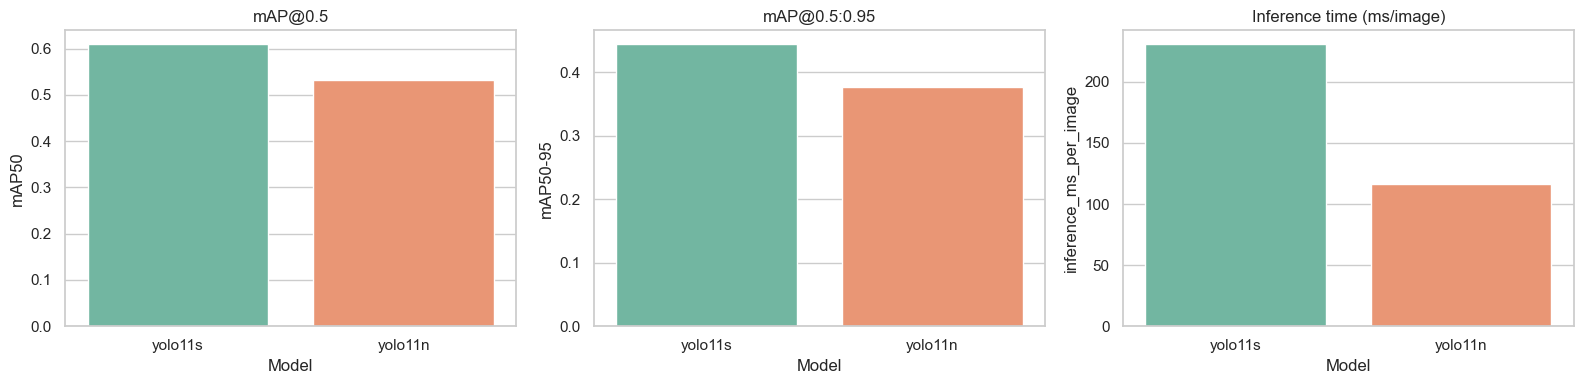

Đã lưu biểu đồ so sánh: /Users/ngonhattoan/IdeaProjects/CO5085_DeepLearning_CV/assignment_2/runs/assignment2_yolov11_coco/report_artifacts/figures/metrics_comparison.png


In [25]:
if result_df.empty:
    print('Chưa có run nào có best.pt để vẽ biểu đồ. Hãy train xong ít nhất 1 mô hình rồi chạy lại cell này.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    sns.barplot(data=result_df, x='model', y='mAP50', ax=axes[0], palette='Set2')
    axes[0].set_title('mAP@0.5')

    sns.barplot(data=result_df, x='model', y='mAP50-95', ax=axes[1], palette='Set2')
    axes[1].set_title('mAP@0.5:0.95')

    sns.barplot(data=result_df, x='model', y='inference_ms_per_image', ax=axes[2], palette='Set2')
    axes[2].set_title('Inference time (ms/image)')

    for ax in axes:
        ax.set_xlabel('Model')
        ax.tick_params(axis='x', rotation=0)

    plt.tight_layout()
    metrics_plot_path = FIG_DIR / 'metrics_comparison.png'
    fig.savefig(metrics_plot_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Đã lưu biểu đồ so sánh: {metrics_plot_path.resolve()}')

Nhìn vào bảng và biểu đồ, có thể đánh giá rõ trade-off giữa độ chính xác và tốc độ giữa hai biến thể YOLOv11.

Mô hình có mAP cao hơn chưa chắc là lựa chọn tốt nhất trong mọi bối cảnh; với các bài toán thời gian thực, độ trễ suy luận là yếu tố cần cân nhắc tương đương.

## **7. Trực quan kết quả dự đoán**
Minh họa detection trên một số ảnh validation để quan sát trực tiếp chất lượng localization và classification.

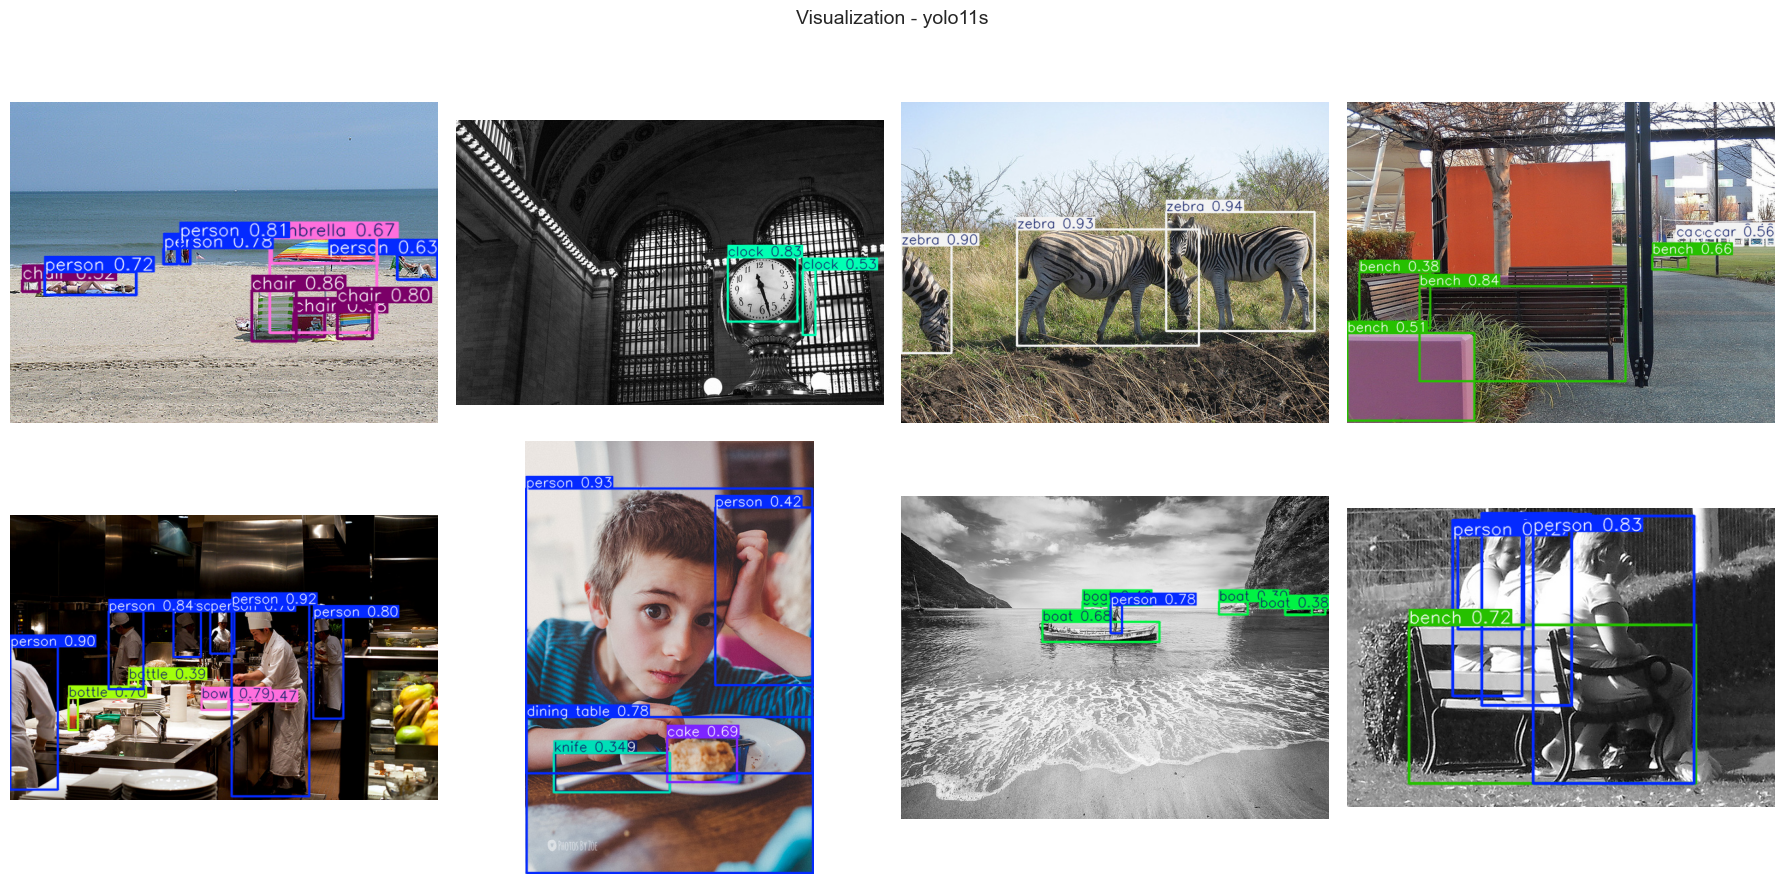

Đã lưu grid visualize: /Users/ngonhattoan/IdeaProjects/CO5085_DeepLearning_CV/assignment_2/runs/assignment2_yolov11_coco/report_artifacts/figures/visualization_grid_yolo11s.png
Đã lưu ảnh prediction riêng lẻ tại: /Users/ngonhattoan/IdeaProjects/CO5085_DeepLearning_CV/assignment_2/runs/assignment2_yolov11_coco/report_artifacts/figures/predictions


In [26]:
if 'DATA_YAML' not in globals():
    USE_COCO128_DEBUG = globals().get('USE_COCO128_DEBUG', False)
    DATA_YAML = 'coco128.yaml' if USE_COCO128_DEBUG else 'coco.yaml'

if 'PROJECT_DIR' not in globals():
    local_runs = globals().get('RUNS_ROOT', resolve_runs_root())
    PROJECT_DIR = Path(local_runs) / 'assignment2_yolov11_coco'

if 'FIG_DIR' not in globals():
    FIG_DIR = PROJECT_DIR / 'report_artifacts' / 'figures'
    FIG_DIR.mkdir(parents=True, exist_ok=True)

if 'result_df' not in globals():
    fallback_experiments = globals().get('experiments', {'yolo11n': 'yolo11n.pt', 'yolo11s': 'yolo11s.pt'})
    rows = []
    for exp_name in fallback_experiments.keys():
        best_weight = PROJECT_DIR / f'{exp_name}_coco' / 'weights' / 'best.pt'
        if best_weight.exists():
            rows.append({'model': exp_name, 'best_weight': str(best_weight)})
    result_df = pd.DataFrame(rows)

if 'val_images' not in globals():
    local_data_info = data_info if 'data_info' in globals() else check_det_dataset(DATA_YAML)
    if 'resolve_path' in globals():
        val_images_path = resolve_path(local_data_info.get('path', '.'), local_data_info['val'])
    else:
        p = Path(local_data_info['val'])
        val_images_path = p if p.is_absolute() else (Path(local_data_info.get('path', '.')) / p)

    if val_images_path.is_file() and val_images_path.suffix.lower() == '.txt':
        val_images = []
        with open(val_images_path, 'r', encoding='utf-8') as f:
            for line in f:
                s = line.strip()
                if not s:
                    continue
                p = Path(s)
                if not p.is_absolute():
                    p = Path(local_data_info.get('path', '.')) / p
                if p.exists():
                    val_images.append(p)
        val_images = sorted(val_images)
    else:
        val_images = sorted(
            list(val_images_path.glob('*.jpg')) +
            list(val_images_path.glob('*.jpeg')) +
            list(val_images_path.glob('*.png'))
        )

if result_df.empty:
    print('Không có kết quả đánh giá để trực quan. Hãy chạy Section 6 sau khi đã có best.pt.')
elif 'best_weight' not in result_df.columns:
    print('Thiếu cột best_weight trong result_df. Hãy chạy lại Section 6 trước.')
elif len(val_images) == 0:
    print('Không tìm thấy ảnh validation để trực quan hóa.')
else:
    best_model_name = str(result_df.iloc[0]['model'])
    best_model_path = Path(result_df.iloc[0]['best_weight'])
    if not best_model_path.exists():
        print(f'Không tìm thấy best.pt tại {best_model_path}. Hãy train/evaluate lại Section 5-6.')
    else:
        best_model = YOLO(str(best_model_path))
        sample_images = random.sample(val_images, k=min(8, len(val_images)))
        pred_results = best_model.predict(source=[str(p) for p in sample_images], conf=0.25, save=False, verbose=False)

        pred_dir = FIG_DIR / 'predictions'
        pred_dir.mkdir(parents=True, exist_ok=True)

        fig, axes = plt.subplots(2, 4, figsize=(18, 9))
        axes = axes.flatten()
        for i, (ax, pred) in enumerate(zip(axes, pred_results), start=1):
            plotted = pred.plot()[:, :, ::-1]
            ax.imshow(plotted)
            ax.axis('off')
            plt.imsave(pred_dir / f'{best_model_name}_sample_{i:02d}.png', plotted)

        for i in range(len(pred_results), len(axes)):
            axes[i].axis('off')

        plt.suptitle(f'Visualization - {best_model_name}', fontsize=14)
        plt.tight_layout()
        grid_path = FIG_DIR / f'visualization_grid_{best_model_name}.png'
        fig.savefig(grid_path, dpi=200, bbox_inches='tight')
        plt.show()

        print(f'Đã lưu grid visualize: {grid_path.resolve()}')
        print(f'Đã lưu ảnh prediction riêng lẻ tại: {pred_dir.resolve()}')

Quan sát định tính giúp bổ sung cho các metric định lượng, đặc biệt trong các trường hợp mô hình phát hiện đúng nhưng confidence thấp hoặc nhầm giữa các lớp gần nhau.

Kết hợp hai góc nhìn định lượng và định tính sẽ giúp phần thảo luận kết quả trong báo cáo thuyết phục hơn.

## **8. Tổng hợp kết quả cho báo cáo**

In [27]:
if 'PROJECT_DIR' not in globals():
    local_runs = globals().get('RUNS_ROOT', resolve_runs_root())
    PROJECT_DIR = Path(local_runs) / 'assignment2_yolov11_coco'

REPORT_DIR = globals().get('REPORT_DIR', PROJECT_DIR / 'report_artifacts')
TABLE_DIR = globals().get('TABLE_DIR', REPORT_DIR / 'tables')
REPORT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

if 'result_df' not in globals() or result_df is None:
    result_df = pd.DataFrame()

experiments = globals().get('experiments', {'yolo11n': 'yolo11n.pt', 'yolo11s': 'yolo11s.pt'})
TRAIN_ARGS = globals().get('TRAIN_ARGS', {})

if 'run_registry' not in globals() or run_registry is None:
    run_registry = {}
    for exp_name in experiments.keys():
        run_dir = PROJECT_DIR / f'{exp_name}_coco'
        best_weight = run_dir / 'weights' / 'best.pt'
        last_weight = run_dir / 'weights' / 'last.pt'
        run_registry[exp_name] = {
            'run_dir': run_dir,
            'best_exists': best_weight.exists(),
            'last_exists': last_weight.exists(),
        }

summary_cols = ['model', 'precision', 'recall', 'mAP50', 'mAP50-95', 'inference_ms_per_image']
if result_df.empty:
    summary_df = pd.DataFrame(columns=summary_cols)
else:
    summary_df = result_df.reindex(columns=summary_cols).copy()
    summary_df = summary_df.round({
        'precision': 4,
        'recall': 4,
        'mAP50': 4,
        'mAP50-95': 4,
        'inference_ms_per_image': 2
    })

summary_csv = TABLE_DIR / 'comparison_metrics.csv'
summary_json = TABLE_DIR / 'comparison_metrics.json'
run_meta_yaml = TABLE_DIR / 'run_metadata.yaml'

summary_df.to_csv(summary_csv, index=False)
summary_df.to_json(summary_json, orient='records', force_ascii=False, indent=2)

run_metadata = {
    'dataset_yaml': globals().get('DATA_YAML', 'coco.yaml'),
    'experiments': experiments,
    'train_args': TRAIN_ARGS,
    'run_dirs': {k: str(v['run_dir']) for k, v in run_registry.items()},
    'best_weight_exists': {k: bool(v.get('best_exists', False)) for k, v in run_registry.items()},
    'last_weight_exists': {k: bool(v.get('last_exists', False)) for k, v in run_registry.items()}
}
with open(run_meta_yaml, 'w', encoding='utf-8') as f:
    yaml.safe_dump(run_metadata, f, sort_keys=False, allow_unicode=True)

display(summary_df)
print(f'Đã lưu bảng CSV: {summary_csv.resolve()}')
print(f'Đã lưu bảng JSON: {summary_json.resolve()}')
print(f'Đã lưu metadata run: {run_meta_yaml.resolve()}')

,model,precision,recall,mAP50,mAP50-95,inference_ms_per_image
0,yolo11s,0.6738,0.5592,0.6087,0.4439,230.53
1,yolo11n,0.6418,0.4881,0.5316,0.3767,116.23


Đã lưu bảng CSV: /Users/ngonhattoan/IdeaProjects/CO5085_DeepLearning_CV/assignment_2/runs/assignment2_yolov11_coco/report_artifacts/tables/comparison_metrics.csv
Đã lưu bảng JSON: /Users/ngonhattoan/IdeaProjects/CO5085_DeepLearning_CV/assignment_2/runs/assignment2_yolov11_coco/report_artifacts/tables/comparison_metrics.json
Đã lưu metadata run: /Users/ngonhattoan/IdeaProjects/CO5085_DeepLearning_CV/assignment_2/runs/assignment2_yolov11_coco/report_artifacts/tables/run_metadata.yaml


## **9. Hướng mở rộng**
- So sánh thêm với mô hình khác họ one-stage/two-stage (VD: YOLO11 vs Faster R-CNN/RT-DETR).
- Phân tích lỗi FN/FP theo từng lớp và confusion matrix.
- Đánh giá trade-off tốc độ/chính xác trên nhiều kích thước model (n/s/m/l).
- Demo real-time với webcam/video và triển khai giao diện Gradio/Streamlit.

